# Spam Email Detection

## 04. Model Building and Training

### Algorithms

1. Multinomial Naive Bayes
2. Logistic Regression
3. Linear Support Vector Machine
4. Random Forest

TF-IDF is used to convert text into numerical features.

In [8]:
## output

from pathlib import Path

# Project root
BASE_DIR = Path.cwd().parent.parent

# Dataset
DATA_DIR = BASE_DIR / "data"

# Outputs
OUTPUT_DIR = BASE_DIR / "outputs"
FIGURE_DIR = OUTPUT_DIR / "figures"
RESULT_DIR = OUTPUT_DIR / "results"

# Models
MODEL_DIR = BASE_DIR / "models"

# Create folders
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
RESULT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

DATA_PATH = DATA_DIR / "email.csv"

print("PROJECT:", BASE_DIR)
print("DATASET:", DATA_PATH)
print("FIGURES:", FIGURE_DIR)
print("RESULTS:", RESULT_DIR)
print("MODELS:", MODEL_DIR)

PROJECT: c:\Users\HP\OneDrive\Desktop\Spam-Email-Detection
DATASET: c:\Users\HP\OneDrive\Desktop\Spam-Email-Detection\data\email.csv
FIGURES: c:\Users\HP\OneDrive\Desktop\Spam-Email-Detection\outputs\figures
RESULTS: c:\Users\HP\OneDrive\Desktop\Spam-Email-Detection\outputs\results
MODELS: c:\Users\HP\OneDrive\Desktop\Spam-Email-Detection\models


In [9]:
import pandas as pd
import numpy as np

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import SelectKBest, chi2

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

BASE_DIR = Path.cwd().parent.parent

DATA_PATH = BASE_DIR / "data" / "email.csv"

RESULT_DIR = BASE_DIR / "outputs" / "results"

RESULT_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(DATA_PATH)

df["Category"] = df["Category"].astype(str).str.strip().str.lower()

df = df[
    df["Category"].isin(["ham", "spam"])
].copy()

df["Message"] = df["Message"].astype(str)

df = df.drop_duplicates()

df["label"] = df["Category"].map({
    "ham": 0,
    "spam": 1
})

X = df["Message"]
y = df["label"]

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [11]:
models = {

    "Multinomial Naive Bayes": Pipeline([
        (
            "tfidf",
            TfidfVectorizer(
                stop_words="english",
                ngram_range=(1, 2),
                min_df=2,
                max_df=0.95
            )
        ),
        (
            "select",
            SelectKBest(
                chi2,
                k=3000
            )
        ),
        (
            "model",
            MultinomialNB()
        )
    ]),

    "Logistic Regression": Pipeline([
        (
            "tfidf",
            TfidfVectorizer(
                stop_words="english",
                ngram_range=(1, 2),
                min_df=2,
                max_df=0.95,
                sublinear_tf=True
            )
        ),
        (
            "select",
            SelectKBest(
                chi2,
                k=3000
            )
        ),
        (
            "model",
            LogisticRegression(
                max_iter=2000,
                class_weight="balanced",
                random_state=42
            )
        )
    ]),

    "Linear SVM": Pipeline([
        (
            "tfidf",
            TfidfVectorizer(
                stop_words="english",
                ngram_range=(1, 2),
                min_df=2,
                max_df=0.95,
                sublinear_tf=True
            )
        ),
        (
            "select",
            SelectKBest(
                chi2,
                k=3000
            )
        ),
        (
            "model",
            LinearSVC(
                class_weight="balanced",
                random_state=42
            )
        )
    ])
}

In [12]:
results = []

trained_models = {}

for name, model in models.items():

    print("Training:", name)

    model.fit(
        X_train,
        y_train
    )

    predictions = model.predict(X_test)

    accuracy = accuracy_score(
        y_test,
        predictions
    )

    precision = precision_score(
        y_test,
        predictions,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        predictions,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        predictions,
        zero_division=0
    )

    if hasattr(
        model,
        "predict_proba"
    ):
        score = model.predict_proba(
            X_test
        )[:, 1]

    else:
        score = model.decision_function(
            X_test
        )

    auc = roc_auc_score(
        y_test,
        score
    )

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1_Score": f1,
        "ROC_AUC": auc
    })

    trained_models[name] = model

model_results = pd.DataFrame(results)

model_results.to_csv(
    RESULT_DIR / "13_model_comparison.csv",
    index=False
)

model_results

Training: Multinomial Naive Bayes
Training: Logistic Regression
Training: Linear SVM


,Model,Accuracy,Precision,Recall,F1_Score,ROC_AUC
0,Multinomial Naive Bayes,0.968023,1.000000,0.742188,0.852018,0.985386
1,Logistic Regression,0.975775,0.912000,0.890625,0.901186,0.990701
2,Linear SVM,0.977713,0.933884,0.882812,0.907631,0.992654


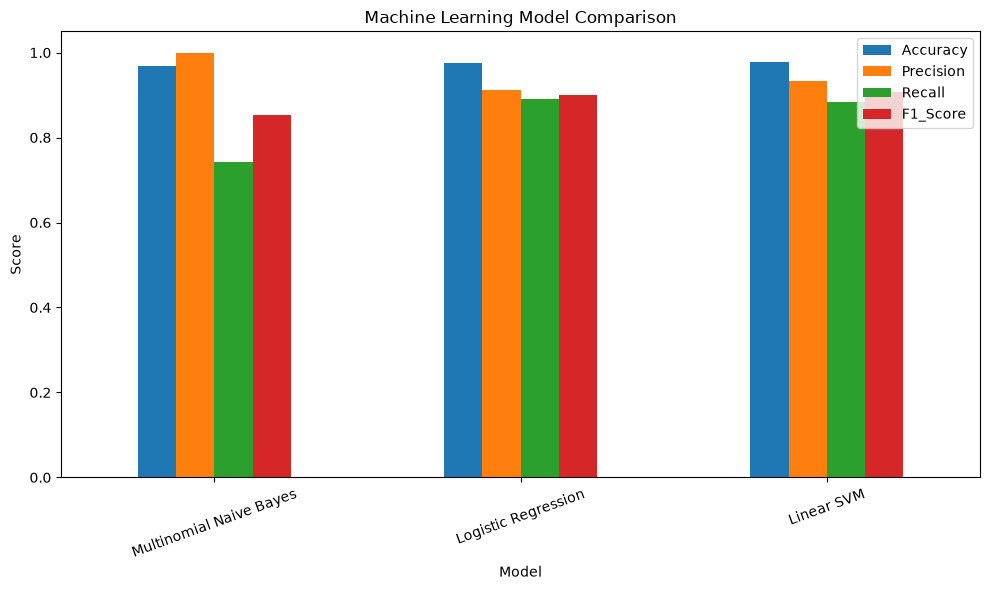

In [13]:
import matplotlib.pyplot as plt

model_results.set_index(
    "Model"
)[
    ["Accuracy", "Precision", "Recall", "F1_Score"]
].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Machine Learning Model Comparison")
plt.ylabel("Score")
plt.xlabel("Model")

plt.xticks(rotation=20)

plt.tight_layout()

plt.savefig(
    BASE_DIR / "outputs" / "figures" /
    "07_model_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [14]:
# ============================================================
# RANDOM FOREST WITH SVD
# ============================================================

from sklearn.decomposition import TruncatedSVD
from sklearn.ensemble import RandomForestClassifier

vectorizer = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95
)

Xtr = vectorizer.fit_transform(X_train)
Xte = vectorizer.transform(X_test)

svd = TruncatedSVD(
    n_components=100,
    random_state=42
)

Xtr_svd = svd.fit_transform(Xtr)
Xte_svd = svd.transform(Xte)

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

rf.fit(
    Xtr_svd,
    y_train
)

rf_pred = rf.predict(Xte_svd)

rf_result = pd.DataFrame([{
    "Model": "Random Forest",
    "Accuracy": accuracy_score(y_test, rf_pred),
    "Precision": precision_score(y_test, rf_pred, zero_division=0),
    "Recall": recall_score(y_test, rf_pred, zero_division=0),
    "F1_Score": f1_score(y_test, rf_pred, zero_division=0),
    "ROC_AUC": roc_auc_score(
        y_test,
        rf.predict_proba(Xte_svd)[:, 1]
    )
}])

rf_result.to_csv(
    RESULT_DIR / "14_random_forest_result.csv",
    index=False
)

rf_result

,Model,Accuracy,Precision,Recall,F1_Score,ROC_AUC
0,Random Forest,0.971899,0.938053,0.828125,0.879668,0.975573
